In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

#cria um dataframe instanciando no objeto "df"
df = pd.read_csv("BaseDPEvolucaoMensalCisp (1).csv",sep = ";", encoding = "latin1")
#Visualiza as 5 primeiras linhas da base de dados para se ter uma noção
df.head()

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,NaN,10,1,3,0,0,0,147,3


In [4]:
#Verifica o tipo de dado de cada coluna. Nesse caso, não é necessário fazer casting, pois as colunas que usaremos para os calculos já são do tipo int 
df[['mes', 'ano', 'munic', 'regiao', 'furto_veiculos', 'recuperacao_veiculos']].info()

<class 'pandas.DataFrame'>
RangeIndex: 37314 entries, 0 to 37313
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   mes                   37314 non-null  int64
 1   ano                   37314 non-null  int64
 2   munic                 37314 non-null  str  
 3   regiao                37314 non-null  str  
 4   furto_veiculos        37314 non-null  int64
 5   recuperacao_veiculos  37314 non-null  int64
dtypes: int64(4), str(2)
memory usage: 1.7 MB


In [5]:
#Soma a quantidade de vezes que cada região aparece na base de dados
df['regiao'].value_counts()

regiao
Interior                         18192
Capital                          11197
Baixada Fluminense                5155
Grande NiterÃÂÃÂÃÂÃÂ³i     2610
Grande Niterói                     160
Name: count, dtype: int64

In [6]:
#Padronizando os nomes da região Grande Niterói
df['regiao'] = df['regiao'].replace({'Grande NiterÃÂÃÂÃÂÃÂ³i': 'Grande Niterói',})

In [7]:
#Soma a quantidade de vezes que cada região aparece na base de dados
df['regiao'].value_counts()

regiao
Interior              18192
Capital               11197
Baixada Fluminense     5155
Grande Niterói         2770
Name: count, dtype: int64

In [8]:
#Criando variáveis para cada região de 2003 à 2026

#Criando uma variável com os dados somente da Capital
df_capital = df[df['regiao'] == 'Capital']
#Filtrando somente as colunas desejadas
df_capital_tratada = df_capital[['mes', 'ano', 'munic', 'regiao', 'furto_veiculos', 'recuperacao_veiculos']]


#Criando uma variável com os dados somente da Baixada Fluminense
df_baixada_fluminense = df[df['regiao'] == 'Baixada Fluminense']
#Filtrando somente as colunas desejadas
df_baixada_fluminense_tratada = df_baixada_fluminense[['mes', 'ano', 'munic', 'regiao', 'furto_veiculos', 'recuperacao_veiculos']]


#Criando uma variável com os dados somente da Grande Niterói
df_grande_niteroi = df[df['regiao'] == 'Grande Niterói']
#Filtrando somente as colunas desejadas
df_grande_niteroi_tratada = df_grande_niteroi[['mes', 'ano', 'munic', 'regiao', 'furto_veiculos', 'recuperacao_veiculos']]


#Criando uma variável com os dados somente do Interior
df_interior = df[df['regiao'] == 'Interior']
#Filtrando somente as colunas desejadas
df_interior_tratada = df_interior[['mes', 'ano', 'munic', 'regiao', 'furto_veiculos', 'recuperacao_veiculos']]


In [9]:
#Mostra os dados filtrados da Capital de 2003 à 2026 (somente das colunas desejadas)
df_capital_tratada

,mes,ano,munic,regiao,furto_veiculos,recuperacao_veiculos
0,1,2003,Rio de Janeiro,Capital,12,5
1,1,2003,Rio de Janeiro,Capital,9,7
2,1,2003,Rio de Janeiro,Capital,28,10
3,1,2003,Rio de Janeiro,Capital,17,77
4,1,2003,Rio de Janeiro,Capital,12,9
...,...,...,...,...,...,...
37213,1,2026,Rio de Janeiro,Capital,6,48
37214,1,2026,Rio de Janeiro,Capital,8,10
37215,1,2026,Rio de Janeiro,Capital,43,8
37216,1,2026,Rio de Janeiro,Capital,7,10


In [10]:
#Mostra os dados filtrados da Baixada Fluminense de 2003 à 2026 (somente das colunas desejadas)
df_baixada_fluminense_tratada

,mes,ano,munic,regiao,furto_veiculos,recuperacao_veiculos
38,1,2003,Seropédica,Baixada Fluminense,1,2
39,1,2003,Itaguaí,Baixada Fluminense,4,4
40,1,2003,Paracambi,Baixada Fluminense,1,2
41,1,2003,Nova Iguaçu,Baixada Fluminense,37,27
42,1,2003,Mesquita,Baixada Fluminense,9,20
...,...,...,...,...,...,...
37232,1,2026,Japeri,Baixada Fluminense,1,3
37233,1,2026,São João de Meriti,Baixada Fluminense,44,93
37234,1,2026,Magé,Baixada Fluminense,8,6
37235,1,2026,Magé,Baixada Fluminense,6,6


In [11]:
#Mostra os dados filtrados da Grande Niterói de 2003 à 2026 (somente das colunas desejadas)
df_grande_niteroi_tratada

,mes,ano,munic,regiao,furto_veiculos,recuperacao_veiculos
56,1,2003,São Gonçalo,Grande Niterói,34,36
57,1,2003,São Gonçalo,Grande Niterói,16,47
58,1,2003,São Gonçalo,Grande Niterói,18,36
59,1,2003,São Gonçalo,Grande Niterói,2,25
60,1,2003,Niterói,Grande Niterói,52,12
...,...,...,...,...,...,...
37244,1,2026,Niterói,Grande Niterói,2,3
37245,1,2026,Niterói,Grande Niterói,16,9
37246,1,2026,Niterói,Grande Niterói,5,6
37247,1,2026,Niterói,Grande Niterói,11,3


In [12]:
#Mostra os dados filtrados do Interior de 2003 à 2026 (somente das colunas desejadas)
df_interior_tratada

,mes,ano,munic,regiao,furto_veiculos,recuperacao_veiculos
55,1,2003,Itaboraí;Tanguá,Interior,13,30
66,1,2003,Barra do Pirai,Interior,3,1
67,1,2003,Resende,Interior,3,10
68,1,2003,Barra Mansa,Interior,10,6
69,1,2003,Valença,Interior,2,1
...,...,...,...,...,...,...
37309,1,2026,Cachoeiras de Macacu,Interior,2,0
37310,1,2026,Mangaratiba,Interior,7,4
37311,1,2026,Angra dos Reis,Interior,10,5
37312,1,2026,Paraty,Interior,1,3


In [ ]:
#(FILTRANDO SOMENTE A ÚLTIMA DÉCADA)

df_decada = df[(df['ano'] >= 2015) & (df['ano'] <= 2025)]


#(LISTA DAS REGIÕES)

regioes = [
    'Capital',
    'Baixada Fluminense',
    'Grande Niterói',
    'Interior'
]


#(LOOP PARA CADA REGIÃO)

for regiao in regioes:

    #(Filtrando os dados da região)
    dados_regiao = df_decada[
        df_decada['regiao'] == regiao
    ]

    #(Agrupando por ano)
    agrupado = dados_regiao.groupby('ano')[
        ['furto_veiculos', 'recuperacao_veiculos']
    ].sum()

    
    #(INICIO DA ANÁLISE DESCRITIVA)
    

    print(f'\n {regiao} ')

    
    #(FURTO DE VEÍCULOS)
    
    print('\nFURTO DE VEÍCULOS\n')

    print('Média:')
    print(agrupado['furto_veiculos'].mean())

    print('\nMediana:')
    print(agrupado['furto_veiculos'].median())

    print('\nModa:')
    print(agrupado['furto_veiculos'].mode())

    print('\nValor mínimo:')
    print(agrupado['furto_veiculos'].min())

    print('\nValor máximo:')
    print(agrupado['furto_veiculos'].max())

    print('\nDesvio padrão:')
    print(agrupado['furto_veiculos'].std())

    print('\nVariância:')
    print(agrupado['furto_veiculos'].var())

    print('\nQuartis:')
    print(
        agrupado['furto_veiculos'].quantile(
            [0.25, 0.50, 0.75]
        )
    )

    
    #(RECUPERAÇÃO DE VEÍCULOS)
    
    print('\nRECUPERAÇÃO DE VEÍCULOS\n')

    print('Média:')
    print(agrupado['recuperacao_veiculos'].mean())

    print('\nMediana:')
    print(agrupado['recuperacao_veiculos'].median())

    print('\nModa:')
    print(agrupado['recuperacao_veiculos'].mode())

    print('\nValor mínimo:')
    print(agrupado['recuperacao_veiculos'].min())

    print('\nValor máximo:')
    print(agrupado['recuperacao_veiculos'].max())

    print('\nDesvio padrão:')
    print(agrupado['recuperacao_veiculos'].std())

    print('\nVariância:')
    print(agrupado['recuperacao_veiculos'].var())

    print('\nQuartis:')
    print(
        agrupado['recuperacao_veiculos'].quantile(
            [0.25, 0.50, 0.75]
        )
    )


 Capital 

FURTO DE VEÍCULOS

Média:
7303.909090909091

Mediana:
7050.0

Moda:
0     6027
1     6376
2     6710
3     6839
4     6862
5     7050
6     7178
7     7536
8     8213
9     8680
10    8872
Name: furto_veiculos, dtype: int64

Valor mínimo:
6027

Valor máximo:
8872

Desvio padrão:
925.680015398999

Variância:
856883.490909091

Quartis:
0.25    6774.5
0.50    7050.0
0.75    7874.5
Name: furto_veiculos, dtype: float64

RECUPERAÇÃO DE VEÍCULOS

Média:
11428.272727272728

Mediana:
9960.0

Moda:
0      6688
1      7577
2      7910
3      8590
4      9148
5      9960
6     11166
7     12812
8     13811
9     18705
10    19344
Name: recuperacao_veiculos, dtype: int64

Valor mínimo:
6688

Valor máximo:
19344

Desvio padrão:
4340.07334248879

Variância:
18836236.618181817

Quartis:
0.25     8250.0
0.50     9960.0
0.75    13311.5
Name: recuperacao_veiculos, dtype: float64

 Baixada Fluminense 

FURTO DE VEÍCULOS

Média:
4033.909090909091

Mediana:
3944.0

Moda:
0     3115
1     3618
2 

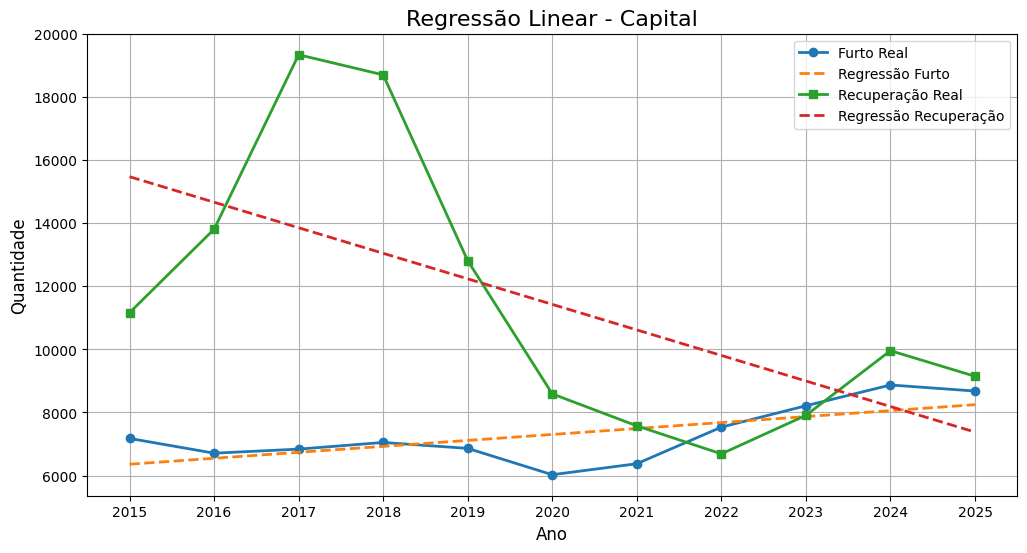


 Capital 

FURTO DE VEÍCULOS &RECUPERAÇÃO DE VEÍCULOS
Coeficiente Angular: 188.78
Intercepto: -374035.36
R²: 0.4575

RECUPERAÇÃO DE VEÍCULOS
Coeficiente Angular: -809.68
Intercepto: 1646985.55
R²: 0.3828


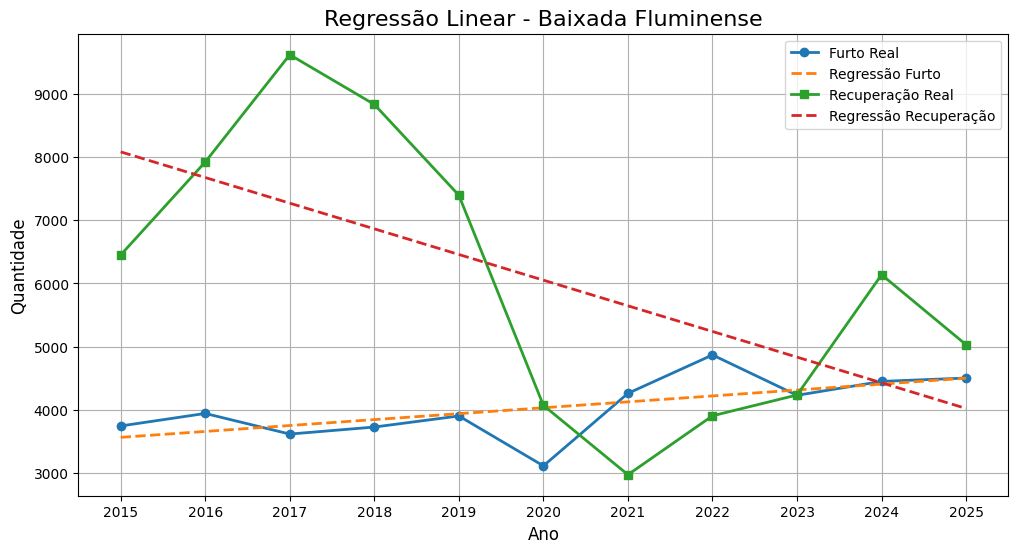


 Baixada Fluminense 

FURTO DE VEÍCULOS &RECUPERAÇÃO DE VEÍCULOS
Coeficiente Angular: 93.59
Intercepto: -185019.73
R²: 0.4012

RECUPERAÇÃO DE VEÍCULOS
Coeficiente Angular: -405.81
Intercepto: 825786.27
R²: 0.3757


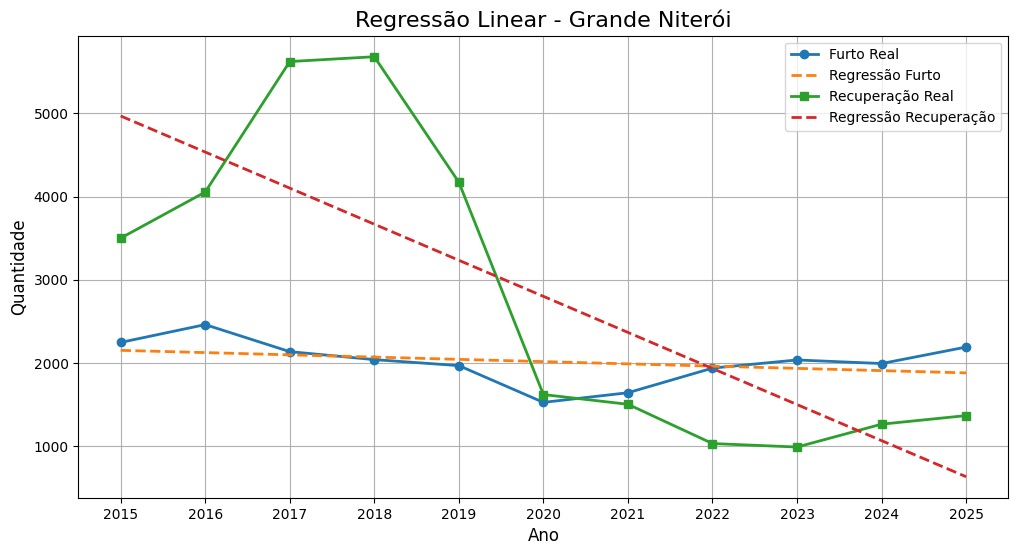


 Grande Niterói 

FURTO DE VEÍCULOS &RECUPERAÇÃO DE VEÍCULOS
Coeficiente Angular: -27.11
Intercepto: 56776.55
R²: 0.1178

RECUPERAÇÃO DE VEÍCULOS
Coeficiente Angular: -433.74
Intercepto: 878948.27
R²: 0.6063


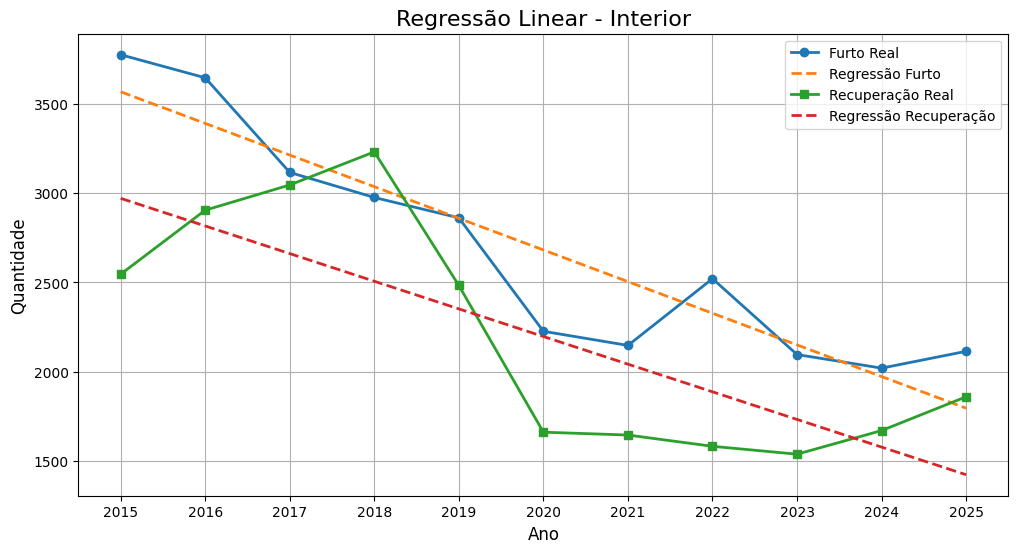


 Interior 

FURTO DE VEÍCULOS &RECUPERAÇÃO DE VEÍCULOS
Coeficiente Angular: -176.88
Intercepto: 359982.82
R²: 0.8519

RECUPERAÇÃO DE VEÍCULOS
Coeficiente Angular: -154.51
Intercepto: 314306.09
R²: 0.6145


In [ ]:

#(Criei um filtro somente para a última década)
df_decada = df[(df['ano'] >= 2015) & (df['ano'] <= 2025)]


#(Ciei uma lista das regiões que serão analisadas e tratadas)
regioes = [
    'Capital',
    'Baixada Fluminense',
    'Grande Niterói',
    'Interior'
]


#(Agora um loop para cada região)

for regiao in regioes:

    #(Filtrando dados da região)
    df_regiao = df_decada[df_decada['regiao'] == regiao]

    #(Criando a variável agrupado, agrupando por ano as somas das colunas furto e recuperação)
    agrupado = df_regiao.groupby('ano')[
        ['furto_veiculos', 'recuperacao_veiculos']
    ].sum().reset_index()

    
    #(Criando a variável X (que é a nossa variável independente) para uso no gráfico, onde o (1) significa uma coluna e o (-1) determina ao python descobrir automaticamente quantas linhas serão necessárias))
    #(O reshape reorganiza o formato e .values transfomra em array Numpy)
    X = agrupado['ano'].values.reshape(-1, 1)

    
    #(FURTO DE VEÍCULOS)

    y_furto = agrupado['furto_veiculos'].values

    modelo_furto = LinearRegression()
    modelo_furto.fit(X, y_furto)

    #(Previsão da regressão)
    y_pred_furto = modelo_furto.predict(X)

    
    #(RECUPERAÇÃO DE VEÍCULOS)
    
    y_rec = agrupado['recuperacao_veiculos'].values

    modelo_rec = LinearRegression()
    modelo_rec.fit(X, y_rec)

    #(Previsão da regressão)
    y_pred_rec = modelo_rec.predict(X)

    
    #(CRIANDO O GRÁFICO E ESTILIZANDO)
    
    plt.figure(figsize=(12,6))

    
    #(Dados reais de furto)
    #(Estilização do gráfico de regressão)
    plt.plot(
        agrupado['ano'],
        y_furto,
        marker='o',
        linewidth=2,
        label='Furto Real'
    )

    
    #(Linha de regressão do furto)
    #(Estilização do gráfico de regressão)
    plt.plot(
        agrupado['ano'],
        y_pred_furto,
        linestyle='--',
        linewidth=2,
        label='Regressão Furto'
    )

    
    #(Dados reais de recuperação)
    #(Estilização do gráfico de regressão)
    plt.plot(
        agrupado['ano'],
        y_rec,
        marker='s',
        linewidth=2,
        label='Recuperação Real'
    )

    
    #(Linha de regressão recuperação)
    #(Estilização do gráfico de regressão)
    plt.plot(
        agrupado['ano'],
        y_pred_rec,
        linestyle='--',
        linewidth=2,
        label='Regressão Recuperação'
    )

    
    #(PERSONALIZAÇÃO)
    
    plt.title(f'Regressão Linear - {regiao}', fontsize=16)

    plt.xlabel('Ano', fontsize=12)
    plt.ylabel('Quantidade', fontsize=12)
    #(Só para lembrar, o 1 é porque avança de 1 em 1, de 2015 até 2025, o 2026 não entra pois o arange para antes do limite, neste caso 2026, para em 2025)
    plt.xticks(np.arange(2015, 2026, 1))

    plt.grid(True)

    plt.legend()

    
    #(MOSTRAR GRÁFICO)
    plt.show()

    
    #(EXIBIR RESULTADOS DA REGRESSÃO)
    print(f'\n {regiao} ')

    print('\nFURTO DE VEÍCULOS', '&' 'RECUPERAÇÃO DE VEÍCULOS')
    print(f'Coeficiente Angular: {modelo_furto.coef_[0]:.2f}')
    print(f'Intercepto: {modelo_furto.intercept_:.2f}')
    print(f'R²: {modelo_furto.score(X, y_furto):.4f}')

    print('\nRECUPERAÇÃO DE VEÍCULOS')
    print(f'Coeficiente Angular: {modelo_rec.coef_[0]:.2f}')
    print(f'Intercepto: {modelo_rec.intercept_:.2f}')
    print(f'R²: {modelo_rec.score(X, y_rec):.4f}')
    


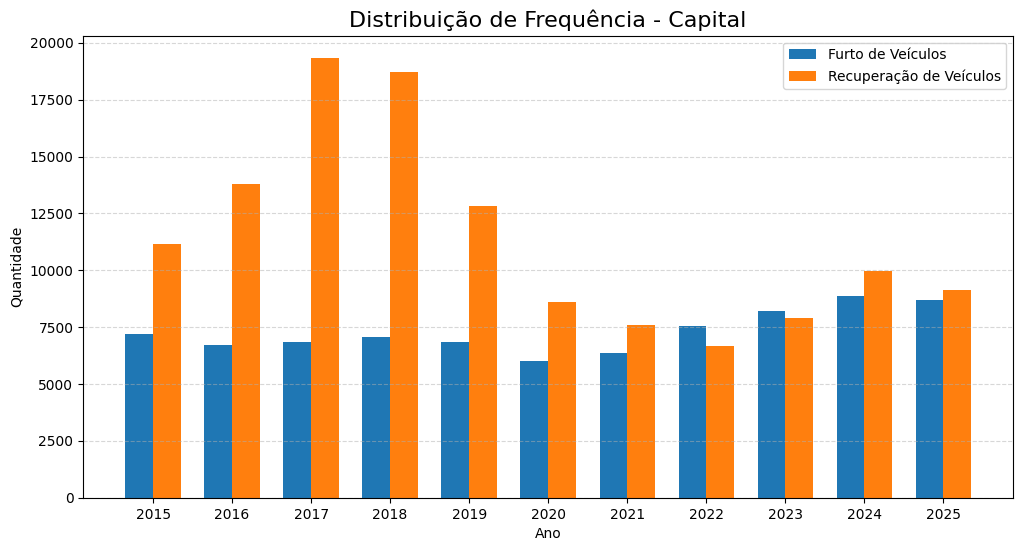

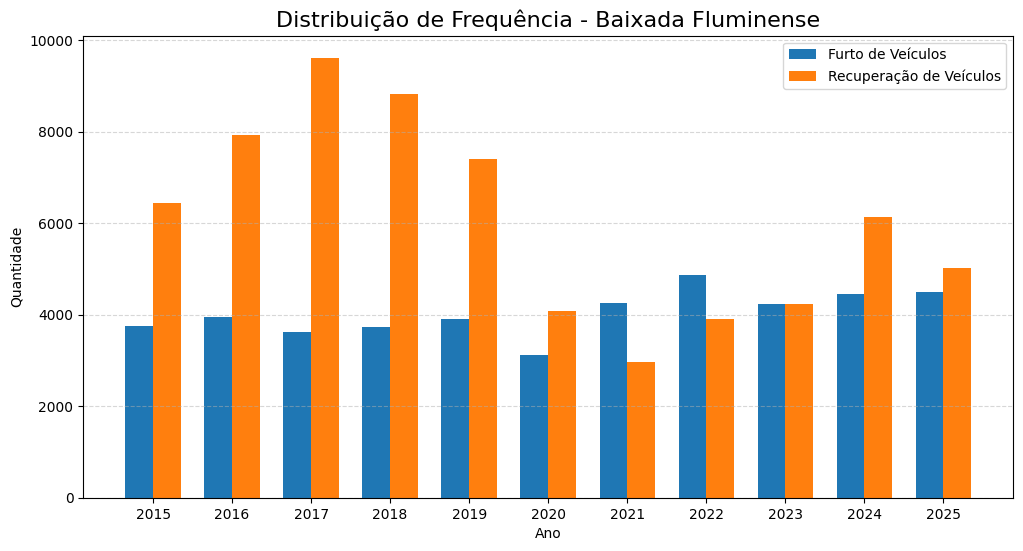

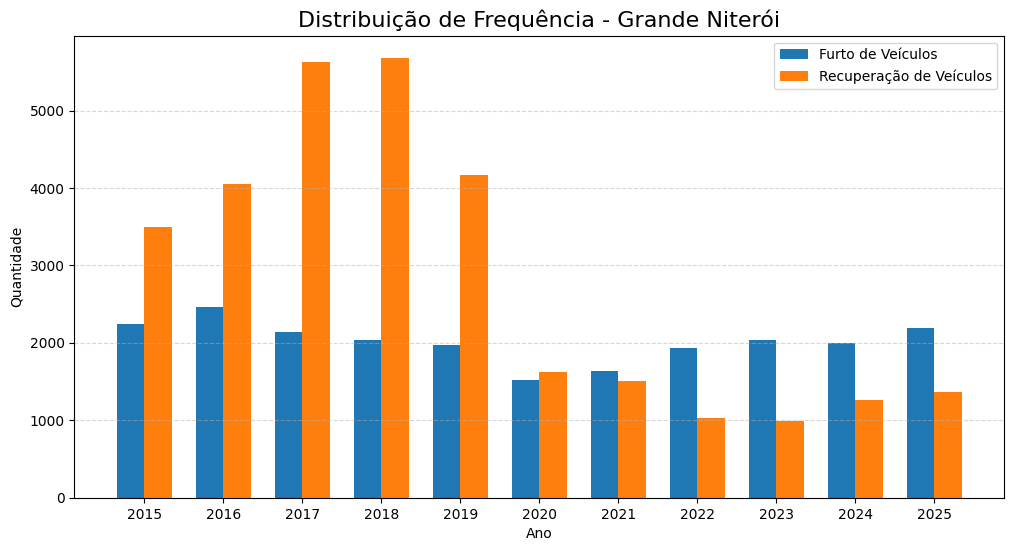

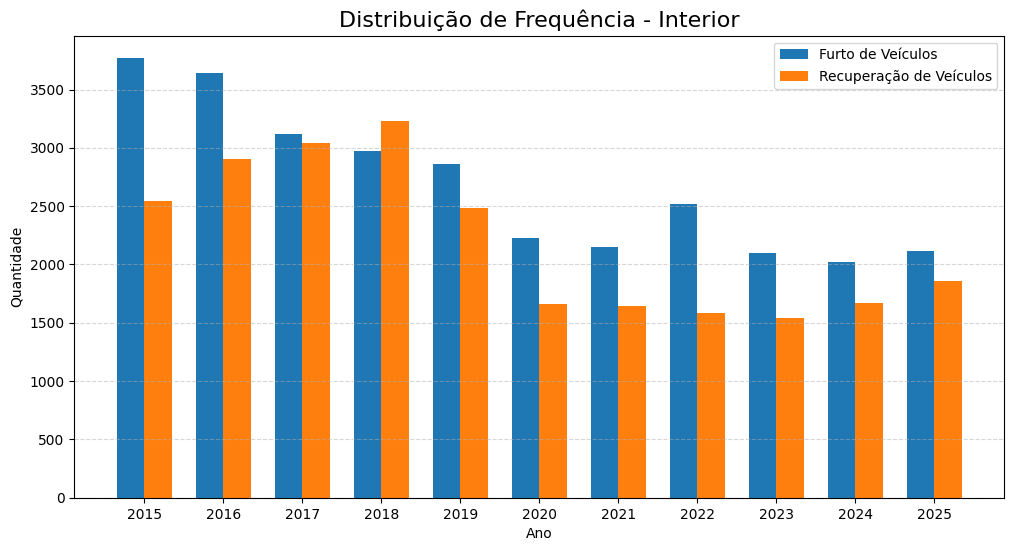

In [31]:
#(Filtrando somente a última década novamente, para não haver erro na interpretação dos dados)
df_decada = df[(df['ano'] >= 2015) & (df['ano'] <= 2025)]

#(Lista das regiões de novo, só para não me perder no código)
regioes = [
    'Capital',
    'Baixada Fluminense',
    'Grande Niterói',
    'Interior'
]

#(Loop para cada região, para rodar cada região dentro do código inteiro antes de rodar a outra região)
for regiao in regioes:

    #(Filtra somente a região atual, aqui os dados da região são filtrados pela década de cada região no loop do for)
    dados_regiao = df_decada[df_decada['regiao'] == regiao]

    #(Soma furtos e recuperações por ano, utilizando a função 'sum' e agrupado por ano utilizando a função 'groupby')
    frequencia = dados_regiao.groupby('ano')[
        ['furto_veiculos', 'recuperacao_veiculos']
    ].sum()

    #(Variável 'X' para usar na criação da posição das barras, array/range e comprimento com contagem de quantos elementos dos indices(index), cria uma sequência numérica)
    x = np.arange(len(frequencia.index))

    # (variável (largura) para usar na Largura das barras do gráfico da distribuição de frequência )
    largura = 0.35

    #(Tamanho da figura, posso ajustar para caber nos slides)
    plt.figure(figsize=(12,6))

    #(Barras de furtos)
    plt.bar(
        x - largura/2,
        frequencia['furto_veiculos'],
        largura,
        label='Furto de Veículos'
    )

    #(Barras de recuperação)
    plt.bar(
        x + largura/2,
        frequencia['recuperacao_veiculos'],
        largura,
        label='Recuperação de Veículos'
    )

    #(Título da distribuição de frequência)
    plt.title(
        f'Distribuição de Frequência - {regiao}',
        fontsize=16
    )

    #(Nome dos eixos)
    plt.xlabel('Ano')
    plt.ylabel('Quantidade')

    #(Colocando os anos no eixo X, a função .xticks controla os valores e rótulos do eixo)
    plt.xticks(x, frequencia.index)

    #(Grade suave, a função grid ativa as linhas do gráfico, axis define o eixo 'y', linestyle as linhas tracejadas e alpha a transparência destas linhas)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Legenda
    plt.legend()

    # Mostrar gráfico
    plt.show()

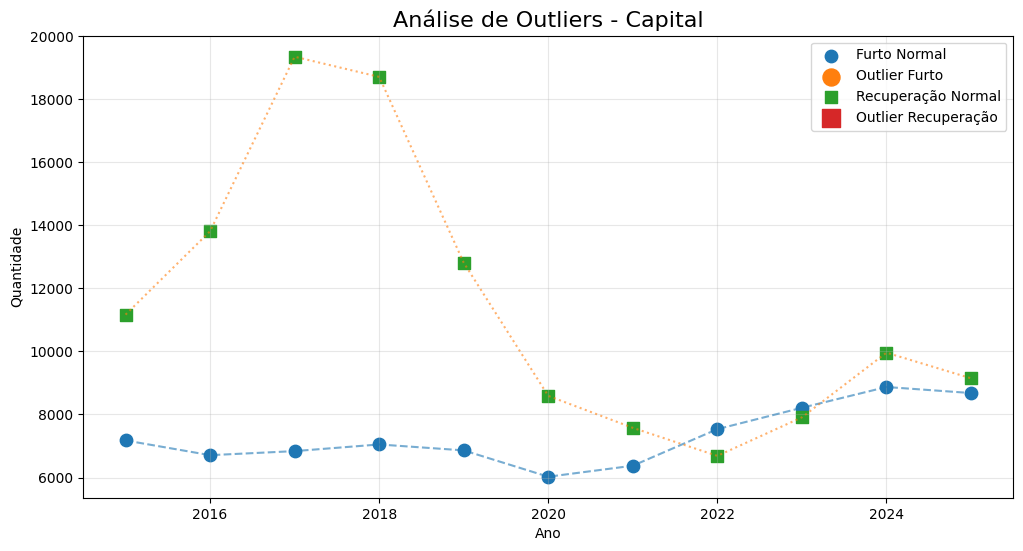


Capital

Outliers - Furto de Veículos
Series([], Name: furto_veiculos, dtype: int64)

Outliers - Recuperação de Veículos
Series([], Name: recuperacao_veiculos, dtype: int64)


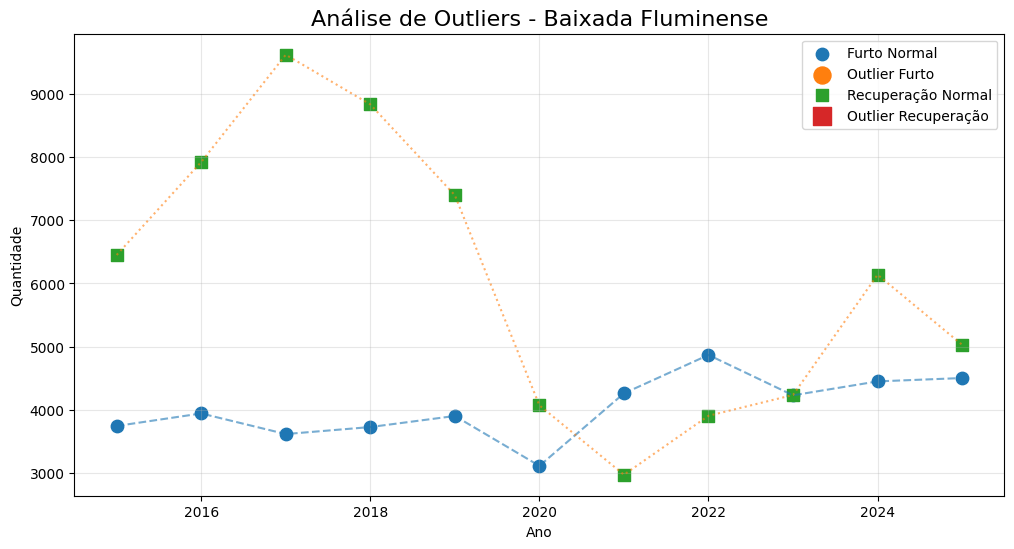


Baixada Fluminense

Outliers - Furto de Veículos
Series([], Name: furto_veiculos, dtype: int64)

Outliers - Recuperação de Veículos
Series([], Name: recuperacao_veiculos, dtype: int64)


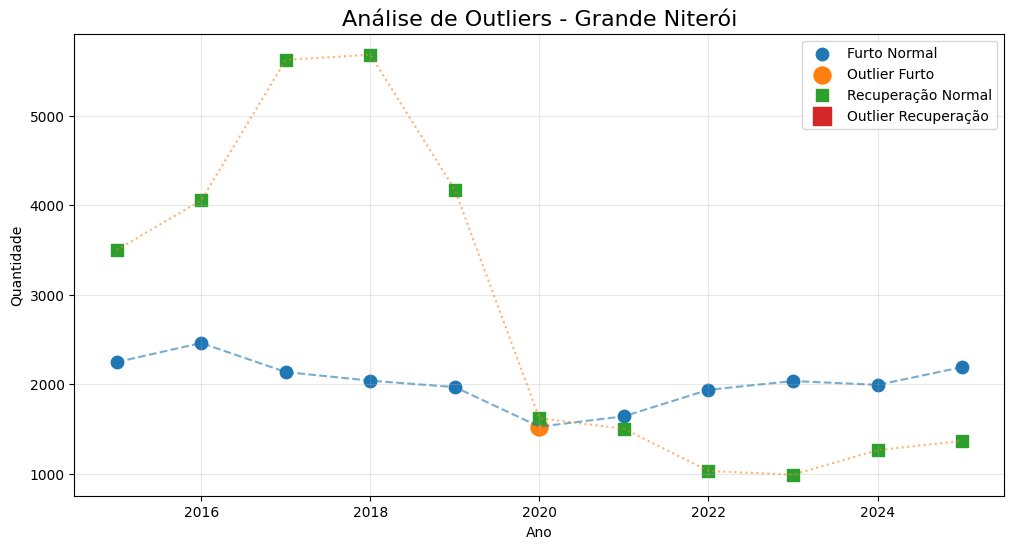


Grande Niterói

Outliers - Furto de Veículos
ano
2020    1526
Name: furto_veiculos, dtype: int64

Outliers - Recuperação de Veículos
Series([], Name: recuperacao_veiculos, dtype: int64)


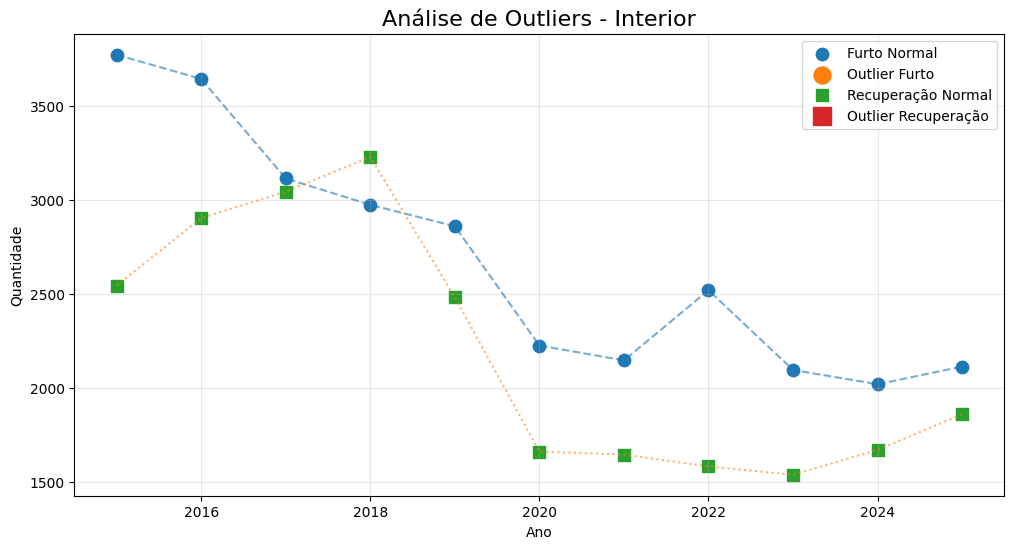


Interior

Outliers - Furto de Veículos
Series([], Name: furto_veiculos, dtype: int64)

Outliers - Recuperação de Veículos
Series([], Name: recuperacao_veiculos, dtype: int64)


In [ ]:


#(FILTRANDO SOMENTE A ÚLTIMA DÉCADA DE NOVO)
df_decada = df[(df['ano'] >= 2015) & (df['ano'] <= 2025)]


#(LISTA DAS REGIÕES DE NOVO)
regioes = [
    'Capital',
    'Baixada Fluminense',
    'Grande Niterói',
    'Interior'
]

#(LOOP PARA CADA REGIÃO DE NOVO)
for regiao in regioes:

    # Filtra os dados da região
    dados_regiao = df_decada[
        df_decada['regiao'] == regiao
    ]

    #(Agrupa por ano)
    agrupado = dados_regiao.groupby('ano')[
        ['furto_veiculos', 'recuperacao_veiculos']
    ].sum()

    #(OUTLIER - FURTO DE VEÍCULOS)
    furto = agrupado['furto_veiculos']

    #(Quartis, Q1 É O PRIMEIRO QUARTIL E Q3 O TERCEIRO QUARTIL) calcula o valor do qual estão 25% dos dados e 75% dos dados
    Q1_furto = furto.quantile(0.25)
    Q3_furto = furto.quantile(0.75)

    #(IQR MÉDIA DO TERCEIRO QUARTIL MENOS O PRIMEIRO QUARTIL) representa a faixa onde estão os 50% centrais dos dados para definir o que é normal ou não
    IQR_furto = Q3_furto - Q1_furto

    #(Limites) defini os limites da zona normal para achar o outlier baixo e alto. 1.5 é o multiplicador padrão criado pelo John Tukey
    limite_inf_furto = Q1_furto - 1.5 * IQR_furto
    limite_sup_furto = Q3_furto + 1.5 * IQR_furto

    #(Identificando outliers) filtra os dados calculados acima e guarda
    outliers_furto = furto[
        (furto < limite_inf_furto) |
        (furto > limite_sup_furto)
    ]

    #(OUTLIER - RECUPERAÇÃO DE VEÍCULOS)
    recuperacao = agrupado['recuperacao_veiculos']

    #(Quartis) calcula o valor do qual estão 25% dos dados e 75% dos dados
    Q1_rec = recuperacao.quantile(0.25)
    Q3_rec = recuperacao.quantile(0.75)

    #(IQR) representa a faixa onde estão os 50% centrais dos dados para definir o que é normal ou não
    IQR_rec = Q3_rec - Q1_rec

    #(Limites) defini os limites da zona normal para achar o outlier baixo e alto. 1.5 é o multiplicador padrão criado pelo John Tukey
    limite_inf_rec = Q1_rec - 1.5 * IQR_rec
    limite_sup_rec = Q3_rec + 1.5 * IQR_rec

    #(Identificando outliers) filtra os dados calculados acima e guarda
    outliers_rec = recuperacao[
        (recuperacao < limite_inf_rec) |
        (recuperacao > limite_sup_rec)
    ]


    #(CRIANDO GRÁFICO)
    plt.figure(figsize=(12,6))

    #(FURTOS NORMAIS, A FUNÇÃO SCATTER CRIA UM GRÁFICO DE DISPERSÃO PARA VISUALIZAR A RELAÇÃO ENTRE DUAS VARIÁVEIS, COM TITULO E ROTULO NOS EIXOS ADICIONADOS)
    plt.scatter(
        furto.index,
        furto.values,
        s=80,
        label='Furto Normal'
    )

    #(Linha de tendência) furtos normais
    plt.plot(
        furto.index,
        furto.values,
        linestyle='--',
        alpha=0.6
    )

    #(Outliers de furto)
    plt.scatter(
        outliers_furto.index,
        outliers_furto.values,
        s=150,
        label='Outlier Furto'
    )

    # RECUPERAÇÕES NORMAIS
    plt.scatter(
        recuperacao.index,
        recuperacao.values,
        s=80,
        marker='s',
        label='Recuperação Normal'
    )

    # Linha recuperação
    plt.plot(
        recuperacao.index,
        recuperacao.values,
        linestyle=':',
        alpha=0.6
    )

    # Outliers recuperação
    plt.scatter(
        outliers_rec.index,
        outliers_rec.values,
        s=150,
        marker='s',
        label='Outlier Recuperação'
    )

    # PERSONALIZAÇÃO
    plt.title(
        f'Análise de Outliers - {regiao}',
        fontsize=16
    )

    plt.xlabel('Ano')
    plt.ylabel('Quantidade')

    plt.grid(alpha=0.3)

    plt.legend()

    plt.show()

    # RESULTADOS
    print(f'\n{regiao}')

    print('\nOutliers - Furto de Veículos')
    print(outliers_furto)

    print('\nOutliers - Recuperação de Veículos')
    print(outliers_rec)